<a href="https://colab.research.google.com/github/Albedofan69420/SIMPSONS-CNN/blob/main/Evaluaci%C3%B3n2_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes

*   Soledad Faúndez



#Comprensión del caso

Se comprende la poseción de un dataset llamado "The Simpsons Characters Data", el cual contiene más de 20.000 imágenes de 42 personajes diferentes de la famosa serie animada "Los Simpsons", los cuales se contienen dentro de carpetas identificadas con los nombres de cada uno.

##Objetivos del modelo

1.- Desarrollar un modelo con CNN para identificar patrones a partir de las imágenes de cada uno de los personajes de la serie, con el propósito de clasificar nuevas imágenes de forma correctamente.

2.- Realizar variadas pruebas en base a diferentes hiperparametros y comparación de modelos para lograr identificar el mejor modelo para clasificar imágenes de los Simpsons.

#Carga y preprocesamiento de datos

In [1]:
!pip install gdown

In [2]:
#Se importan las librerias necesarias para poder trabajar a lo largo del documento

from google.colab.patches import cv2_imshow
import cv2
import glob
import gdown
import os
import itertools
import tensorflow as tf
from tensorflow import keras
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Activation , Dropout, Flatten, BatchNormalization, Conv2D, MaxPooling2D
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
from keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [3]:
#Se descargan los sets de datos necesarios (train y test respectivamente) y los descomprime
file_id = '1B-RXOFSXiPHva-E_X5yPFlore_zlN-4d'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data.tar.gz'

gdown.download(url, output, quiet=True)
!tar -xzvf data.tar.gz

second_file_id = '1OwJI6tQSu90cbo91yCI43JK6-Zh22Cpp'
second_url = f'https://drive.google.com/uc?id={second_file_id}'
second_output = 'second_data.tar.gz'

gdown.download(second_url, second_output, quiet=True)
!tar -xzvf second_data.tar.gz

Se han truncado las últimas 5000 líneas del flujo de salida.
simpsons/mayor_quimby/pic_0116.jpg
simpsons/milhouse_van_houten/pic_0576.jpg
simpsons/lenny_leonard/pic_0149.jpg
simpsons/kent_brockman/pic_0446.jpg
simpsons/nelson_muntz/pic_0060.jpg
simpsons/krusty_the_clown/pic_0838.jpg
simpsons/homer_simpson/pic_0637.jpg
simpsons/homer_simpson/pic_0495.jpg
simpsons/krusty_the_clown/pic_0893.jpg
simpsons/homer_simpson/pic_0834.jpg
simpsons/homer_simpson/pic_0692.jpg
simpsons/lisa_simpson/pic_0755.jpg
simpsons/marge_simpson/pic_0654.jpg
simpsons/chief_wiggum/pic_0344.jpg
simpsons/lisa_simpson/pic_0952.jpg
simpsons/lisa_simpson/pic_1269.jpg
simpsons/marge_simpson/pic_0851.jpg
simpsons/marge_simpson/pic_1168.jpg
simpsons/chief_wiggum/pic_0541.jpg
simpsons/homer_simpson/pic_1948.jpg
simpsons/sideshow_bob/pic_0104.jpg
simpsons/lisa_simpson/pic_0278.jpg
simpsons/nelson_muntz/pic_0128.jpg
simpsons/marge_simpson/pic_0177.jpg
simpsons/milhouse_van_houten/pic_0699.jpg
simpsons/waylon_smithers/pic_00

In [4]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a estandarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

In [5]:
#Carga los datos de training en imágenes etiquetadas
def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [6]:
#Esta función funciona de manera equivalente a la función load_train_set pero cargando los datos de test. Extrae los nombres de las fotos y etiqueta
def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

In [7]:
# Cargamos los datos
DATASET_TRAIN_PATH_COLAB = "simpsons"
DATASET_TEST_PATH_COLAB = "simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [8]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

In [9]:
#Normalización de datos
X_train = X / 255.0
X_test = X_t / 255.0

X_train, X_val, Y_train, Y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Verificación de dimensiones. Se ven representados la cantidad de datos, resolución y RGB
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (15193, 64, 64, 3)
Y_train: (15193,)


Dentro de la etapa de preprocesamiento de datos se hicieron los siguientes cambios:

*   Se redimensionaron las imágenes del dataset a un estandar definido de 64 x 64 pixeles para estandarizar el tamaño de las imágenes y reducir el costo computacional.
*   Se normalizaron los pixeles para que estos se encuentren en rangos entre el 0 y el 1 para equilibrar los pesos iniciales y acelerar el tiempo de aprendizaje de los modelos a desarrollar.
*   Se dividió el set de datos en training/validation para las posteriores validaciones. Este fue separado en 80/20, siguiendo un estandar de división.
*   Se aleatorizó el orden original de las imágenes contenidas dentro del dataset, con el propósito de evitar la secuencialidad de personajes incluida de forma inicial y permitir la toma variada de datos en caso de ser necesario.





#Definición del modelo CNN

In [10]:
#Se define la creación de un modelo para poder hacer pruebas controladas sobre este
def create_model(
  filter_1 = 32,
  filter_2 = 64,
  neurons = 128,
  dropout = 0.5
):

    model = Sequential([

        Conv2D(filter_1, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),

        Conv2D(filter_2, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        #Convierte en vector 1D
        Flatten(),

        #Define el uso de 128 neuronas
        Dense(neurons, activation='relu'),

        Dense(len(MAP_CHARACTERS), activation='softmax')
    ])

    model.compile(
      optimizer= 'adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
    )

    return model

In [11]:
model_test1 = create_model()
model_test1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,474 (6.21 MB)

 Trainable params: 1,627,474 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

*   Se definió un modelo CNN base simple, con el que se es capaz de aplicar mejoras durante el desarrollo del informe basadas en las necesidades que se identifiquen.
*   Se implementó una doble capa de filtros Conv2D con el propósito de identificar caracteristicas de forma detallada a partir de las imágenes de los personajes.
*   Se lograron identificar una gran cantidad de parámetros entrenables (alrededor de 1.627.474), por lo que se es posible asegurar que el modelo posee una gran capacidad de aprendizaje, así como también de sobreajuste si es que no se manejan correctamente los datos.





#Entrenamiento y ajuste de hiperparametros

##Primer entrenamiento

Como primera prueba se decidió aplicar una cantidad base de 30 épocas y 32 de batch size. Estos valores se definieron basandonos en que se esta realizando una investigación inicial de valores bajos, por lo que despues se abordarán más cantidades.

In [12]:
np.random.seed(30)
tf.random.set_seed(30)

model_test1 = create_model()

hist_model_test1 = model_test1.fit(
    X_train,Y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val,Y_val)
)

Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3311 - loss: 4.8740 - val_accuracy: 0.4556 - val_loss: 1.8078
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5722 - loss: 1.4085 - val_accuracy: 0.5212 - val_loss: 1.7372
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7126 - loss: 0.9564 - val_accuracy: 0.5362 - val_loss: 1.9895
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8031 - loss: 0.6389 - val_accuracy: 0.5501 - val_loss: 2.3796
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8584 - loss: 0.4675 - val_accuracy: 0.5036 - val_loss: 3.3438
Epoch 6/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8947 - loss: 0.3512 - val_accuracy: 0.5678 - val_loss: 2.9904
Epoch 7/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9285 - loss: 0.2364 - val_accuracy: 0.5646 - val_loss: 3.2638
Epoch 8/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9342 - loss: 0.2295 - val_accuracy: 

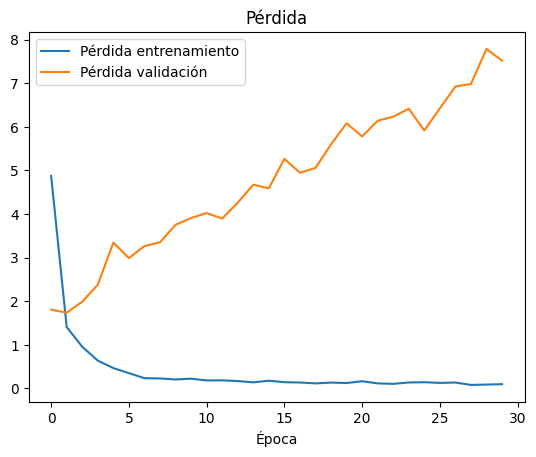

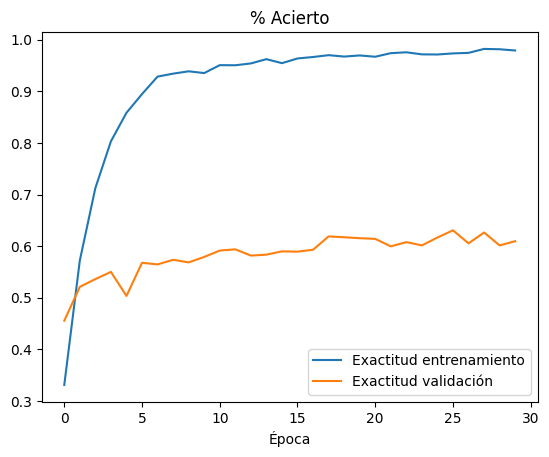

In [13]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_model_test1.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_model_test1.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_model_test1.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_model_test1.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Entrenamiento**

Se logra identificar una perdida sostenida y un acierto elevado, sin grandes fluctuaciones en el aprendizaje, se mantienen demostrando el aprendizaje del modelo.

**Validación**

Se demuestra una baja de la pérdida en base a la cantidad de épocas, con grandes fluctuaciones demuestra un sobreajuste sobre los datos. Por otro lado, los aciertos en la validación se mantienen bajos, con leves fluctuaciones se queda estancado en valores que rozan el 60%-50%.

##Segundo entrenamiento

Como segunda prueba se busca aumentar los valores de los filtros aplicados para las capas de Conv2D, así como también elevar la cantidad de neuronas utilizadas. Para este entrenamiento, también se buscó realizar cambios significativos en lo que son la cantidad de épocas y el batch size, utilizando valores de 50 y 128, respectivamente.

In [18]:
np.random.seed(30)
tf.random.set_seed(30)

model_test2 = create_model(
    filter_1 = 64,
    filter_2 = 128,
    neurons = 256
)

hist_model_test2 = model_test2.fit(
    X_train,Y_train,
    batch_size=128,
    epochs=50,
    validation_data=(X_val,Y_val)
)

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.1998 - loss: 14.4909 - val_accuracy: 0.3443 - val_loss: 2.2065
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4432 - loss: 1.8332 - val_accuracy: 0.4499 - val_loss: 1.9168
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6230 - loss: 1.2458 - val_accuracy: 0.4830 - val_loss: 2.0412
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7359 - loss: 0.8762 - val_accuracy: 0.5046 - val_loss: 2.0783
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8200 - loss: 0.6005 - val_accuracy: 0.5101 - val_loss: 2.3625
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8928 - loss: 0.3571 - val_accuracy: 0.5317 - val_loss: 2.6576
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9336 - loss: 0.2274 - val_accuracy: 0.5159 - val_loss: 2.9984
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9425 - loss: 0.1997 - val_acc

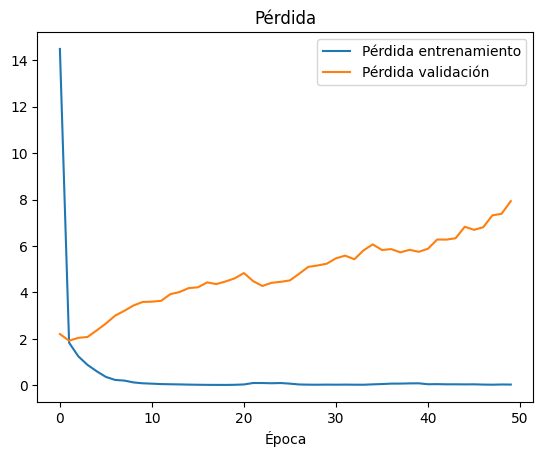

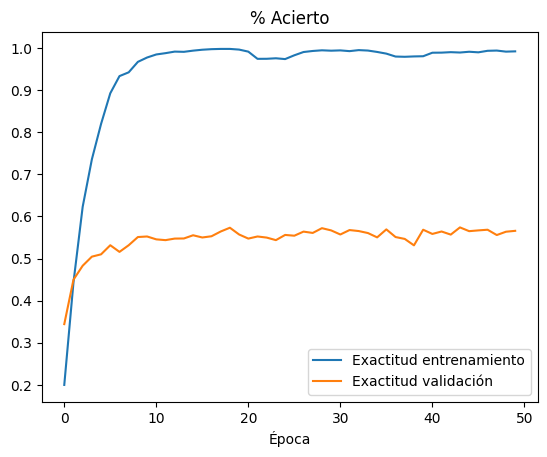

In [19]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_model_test2.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_model_test2.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_model_test2.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_model_test2.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

##Tercer entrenamiento

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_model_test2.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_model_test2.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_model_test2.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_model_test2.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

##Conclusiones parciales

*   Aplicación de dropout:
*   Elemento de lista



#Elección de optimizador

#Aplicación de dropout